In [1]:
# # 1. Install the package
# !git clone https://github.com/JKCooper2/gym-bandits.git
# %cd gym-bandits
# !pip install -e .

# 2. Import Libraries
import gym
import gym_bandits
import numpy as np
import matplotlib.pyplot as plt

# 3. Create Environment
# We typically wrap this to handle deprecated warnings or API changes if necessary, 
# but here we use the standard call.
env = gym.make("BanditTenArmedGaussian-v0")

# 4. Define the Agent
class EpsilonGreedyAgent:
    def __init__(self, epsilon, n_arms):
        self.epsilon = epsilon
        self.n_arms = n_arms
        self.q_values = np.zeros(n_arms)
        self.action_counts = np.zeros(n_arms)

    def select_action(self):
        # Exploration: Random arm
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.n_arms)
        # Exploitation: Best known arm
        else:
            # Use random tie-breaking
            return np.random.choice(np.flatnonzero(self.q_values == self.q_values.max()))

    def update_q_values(self, action, reward):
        self.action_counts[action] += 1
        # Q(a) = Q(a) + 1/N(a) * (R - Q(a))
        self.q_values[action] += (reward - self.q_values[action]) / self.action_counts[action]

# 5. Initialize parameters
epsilon_greedy_agent = EpsilonGreedyAgent(epsilon=0.1, n_arms=env.action_space.n)
num_steps = 1000  # Number of pulls

# 6. Training Loop
print(f"Training Epsilon Greedy (Eps=0.1) on {env.spec.id}...")
rewards = []

# Note: In Bandits, we typically treat the problem as 1 long episode of N steps, 
# rather than N episodes of 1 step.
env.reset() 

for step in range(num_steps):
    action = epsilon_greedy_agent.select_action()
    
    # Gym API Handling (Handles New vs Old Gym versions)
    step_result = env.step(action)
    
    if len(step_result) == 5:
        # New Gym API: obs, reward, terminated, truncated, info
        _, reward, terminated, truncated, _ = step_result
    else:
        # Old Gym API: obs, reward, done, info
        _, reward, done, _ = step_result
        
    epsilon_greedy_agent.update_q_values(action, reward)
    rewards.append(reward)

# 7. Results
print("\nEstimated Q-Values (Agent's belief):")
print(epsilon_greedy_agent.q_values)
print(f"Average Reward: {np.mean(rewards):.4f}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Training Epsilon Greedy (Eps=0.1) on BanditTenArmedGaussian-v0...

Estimated Q-Values (Agent's belief):
[ 1.2450885   1.41697565 -2.07561285 -0.41306027 -1.18806099 -1.56609936
  0.8519358  -1.1566144   1.50183809  2.76472256]
Average Reward: 2.3894


c:\Python311\Lib\site-packages\gym\utils\passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
c:\Python311\Lib\site-packages\gym\utils\passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
c:\Python311\Lib\site-packages\gym\utils\passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'int'>`
  logger.warn(
c:\Python311\Lib\site-packages\gym\utils\passive_env_checker.py:219: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is 

Running Comparison Simulation...


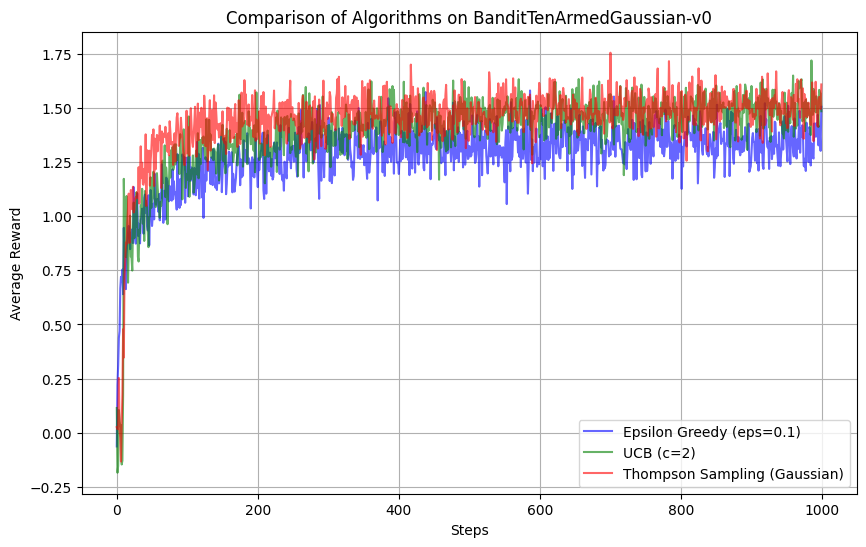

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import gym
import gym_bandits

# --- 1. Define Agents ---

class EpsilonGreedyAgent:
    def __init__(self, n_arms, epsilon=0.1):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.q_values = np.zeros(n_arms)
        self.counts = np.zeros(n_arms)

    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.n_arms)
        return np.argmax(self.q_values)

    def update(self, action, reward):
        self.counts[action] += 1
        self.q_values[action] += (reward - self.q_values[action]) / self.counts[action]

class UCBAgent:
    def __init__(self, n_arms, c=2):
        self.n_arms = n_arms
        self.c = c
        self.q_values = np.zeros(n_arms)
        self.counts = np.zeros(n_arms)
        self.t = 0

    def select_action(self):
        self.t += 1
        if 0 in self.counts:
            return np.argmin(self.counts)
        uncertainty = self.c * np.sqrt(np.log(self.t) / self.counts)
        return np.argmax(self.q_values + uncertainty)

    def update(self, action, reward):
        self.counts[action] += 1
        self.q_values[action] += (reward - self.q_values[action]) / self.counts[action]

# Note: Standard Thompson Sampling uses Beta distributions for Bernoulli rewards (0 or 1).
# Since "BanditTenArmedGaussian" returns continuous rewards (Gaussian), 
# we use Gaussian Thompson Sampling (Normal-Inverse-Gamma prior is ideal, but we will simplify using Normal approximation).
class GaussianThompsonSamplingAgent:
    def __init__(self, n_arms):
        self.n_arms = n_arms
        # Prior: Mean=0, Precision (tau)=0.0001 (High uncertainty)
        self.mu = np.zeros(n_arms) 
        self.tau = np.zeros(n_arms) + 0.0001 

    def select_action(self):
        # Sample from Normal(mu, 1/tau)
        samples = np.random.normal(self.mu, 1 / np.sqrt(self.tau))
        return np.argmax(samples)

    def update(self, action, reward):
        # Bayesian update for Gaussian with known variance (assumed 1)
        # precision_new = precision_old + 1
        # mean_new = (precision_old * mean_old + reward) / precision_new
        old_tau = self.tau[action]
        self.tau[action] += 1
        self.mu[action] = (old_tau * self.mu[action] + reward) / self.tau[action]

# --- 2. Simulation ---

def run_experiment(agent_class, n_arms, steps, **kwargs):
    env = gym.make("BanditTenArmedGaussian-v0")
    env.reset()
    agent = agent_class(n_arms, **kwargs)
    rewards = []
    
    for _ in range(steps):
        action = agent.select_action()
        step_result = env.step(action)
        
        # Handle API
        if len(step_result) == 5:
            _, reward, _, _, _ = step_result
        else:
            _, reward, _, _ = step_result
            
        agent.update(action, reward)
        rewards.append(reward)
    return np.array(rewards)

# Parameters
steps = 1000
runs = 200 # Average over 200 runs for smooth lines
n_arms = 10

print("Running Comparison Simulation...")

# Storage for averaging
avg_r_eps = np.zeros(steps)
avg_r_ucb = np.zeros(steps)
avg_r_ts = np.zeros(steps)

for r in range(runs):
    avg_r_eps += run_experiment(EpsilonGreedyAgent, n_arms, steps, epsilon=0.1)
    avg_r_ucb += run_experiment(UCBAgent, n_arms, steps, c=2)
    avg_r_ts += run_experiment(GaussianThompsonSamplingAgent, n_arms, steps)

avg_r_eps /= runs
avg_r_ucb /= runs
avg_r_ts /= runs

# --- 3. Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(avg_r_eps, label='Epsilon Greedy (eps=0.1)', color='blue', alpha=0.6)
plt.plot(avg_r_ucb, label='UCB (c=2)', color='green', alpha=0.6)
plt.plot(avg_r_ts, label='Thompson Sampling (Gaussian)', color='red', alpha=0.6)

plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.title('Comparison of Algorithms on BanditTenArmedGaussian-v0')
plt.legend()
plt.grid(True)
plt.show()